# Notebook 6: Color-Vision Robustness (Color Weakness / Color Blindness)

Goal: evaluate how robust a fixed CLIP vision–language model is to **simulated color-vision deficiencies**.

We:
- Use **COCO 2017 val** as the in-distribution dataset.
- Simulate several color-vision conditions (e.g., protanopia, deuteranopia, tritanopia).
- Compare **ground-truth COCO category** vs **CLIP predictions** for original vs color-modified images.
- Visualize sample images (original vs simulated) with predicted labels using `matplotlib`.


In [1]:
import os
import random
from typing import List, Dict, Any, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.coco import COCO
from transformers import CLIPProcessor, CLIPModel


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


c:\Users\ROG_STRIX\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Configuration (aligned with main robustness notebook)
CONFIG: Dict[str, Any] = {
    "coco_root": "data/coco",
    "coco_image_subdir": "val2017",  # use all of val2017
    "coco_ann_file": "data/coco/annotations/instances_val2017.json",
    "categories": None,  # None => use ALL COCO categories in 2017 annotations
    "clip_model": "openai/clip-vit-base-patch32",
}

print("COCO root:", CONFIG["coco_root"])
print("Annotation file:", CONFIG["coco_ann_file"])


def load_clip(model_name: str = "openai/clip-vit-base-patch32") -> Tuple[CLIPModel, CLIPProcessor]:
    model = CLIPModel.from_pretrained(model_name).to(device).eval()
    processor = CLIPProcessor.from_pretrained(model_name)
    return model, processor


clip_model, clip_processor = load_clip(CONFIG["clip_model"])
print(f"Loaded CLIP model: {CONFIG['clip_model']}")


COCO root: data/coco
Annotation file: data/coco/annotations/instances_val2017.json


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1635.77it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded CLIP model: openai/clip-vit-base-patch32


In [3]:
from collections import Counter


def load_coco_subset_all(
    coco_root: str,
    ann_file: str,
    categories: List[str] | None,
    image_subdir: str = "val2017",
) -> Tuple[List[Dict[str, Any]], List[str]]:
    """Load all COCO images for the given categories (no per-class cap).

    If ``categories`` is None, use **all** COCO categories from the 2017 annotations.
    Returns (samples, used_categories).
    """
    coco = COCO(ann_file)

    if categories is None:
        cat_ids_all = coco.getCatIds()
        cats = coco.loadCats(cat_ids_all)
        categories = sorted([c["name"] for c in cats])
        print(f"[COCO] categories=None -> using all {len(categories)} categories from annotations.")

    cat_name_to_id: Dict[str, int] = {}
    for cname in categories:
        ids = coco.getCatIds(catNms=[cname])
        if not ids:
            print(f"[COCO] Warning: category '{cname}' not found in annotations.")
            continue
        cat_name_to_id[cname] = ids[0]

    # Aggregate annotations per image so that each image can have multiple labels
    samples_by_image: Dict[int, Dict[str, Any]] = {}
    per_cat_counts: Dict[str, int] = {c: 0 for c in cat_name_to_id.keys()}

    for cname, cid in cat_name_to_id.items():
        img_ids = coco.getImgIds(catIds=[cid])
        for im_id in img_ids:
            ann_ids = coco.getAnnIds(imgIds=im_id, catIds=[cid])
            anns = coco.loadAnns(ann_ids)
            if not anns:
                continue
            # Keep the largest-area instance for this category in this image (for bbox/seg info)
            ann = max(anns, key=lambda a: a.get("area", 0))
            info = coco.loadImgs(im_id)[0]
            fname = info["file_name"]
            img_path = os.path.join(coco_root, image_subdir, fname) if image_subdir else os.path.join(coco_root, fname)
            if not os.path.isfile(img_path):
                continue

            if im_id not in samples_by_image:
                rec: Dict[str, Any] = {
                    "image_path": img_path,
                    "image_id": im_id,
                    "image_height": info["height"],
                    "image_width": info["width"],
                    "category_ids": set(),
                    "category_names": set(),
                    "bboxes": [],
                }
                samples_by_image[im_id] = rec
            else:
                rec = samples_by_image[im_id]

            rec["category_ids"].add(cid)
            rec["category_names"].add(cname)
            bbox = ann.get("bbox", [0.0, 0.0, float(info["width"]), float(info["height"])]),
            rec["bboxes"].append(bbox)
            if ann.get("segmentation"):
                rec.setdefault("segmentations", []).append(ann["segmentation"])
            per_cat_counts[cname] += 1

    # Finalize samples list
    samples: List[Dict[str, Any]] = []
    for rec in samples_by_image.values():
        rec["category_ids"] = sorted(rec["category_ids"])
        rec["category_names"] = sorted(rec["category_names"])
        samples.append(rec)

    print("[COCO] Using ALL images per category (val split):")
    for cname in sorted(per_cat_counts.keys()):
        print(f"  {cname}: {per_cat_counts[cname]}")
    print(f"[COCO] Total images with at least one category: {len(samples)}")

    used_categories = sorted(cat_name_to_id.keys())
    return samples, used_categories


COCO_SAMPLES, COCO_CATEGORIES = load_coco_subset_all(
    coco_root=CONFIG["coco_root"],
    ann_file=CONFIG["coco_ann_file"],
    categories=CONFIG["categories"],
    image_subdir=CONFIG["coco_image_subdir"],
)
len(COCO_SAMPLES)


loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
[COCO] categories=None -> using all 80 categories from annotations.
[COCO] Using ALL images per category (val split):
  airplane: 97
  apple: 76
  backpack: 228
  banana: 103
  baseball bat: 97
  baseball glove: 100
  bear: 49
  bed: 149
  bench: 235
  bicycle: 149
  bird: 125
  boat: 121
  book: 230
  bottle: 379
  bowl: 314
  broccoli: 71
  bus: 189
  cake: 124
  car: 535
  carrot: 81
  cat: 184
  cell phone: 214
  chair: 580
  clock: 204
  couch: 195
  cow: 87
  cup: 390
  dining table: 501
  dog: 177
  donut: 62
  elephant: 89
  fire hydrant: 86
  fork: 155
  frisbee: 84
  giraffe: 101
  hair drier: 9
  handbag: 292
  horse: 128
  hot dog: 51
  keyboard: 106
  kite: 91
  knife: 181
  laptop: 183
  microwave: 54
  motorcycle: 159
  mouse: 88
  orange: 85
  oven: 115
  parking meter: 37
  person: 2693
  pizza: 153
  potted plant: 172
  refrigerator: 101
  remote: 145
  sandwich: 98
  scissors: 28
  she

4952

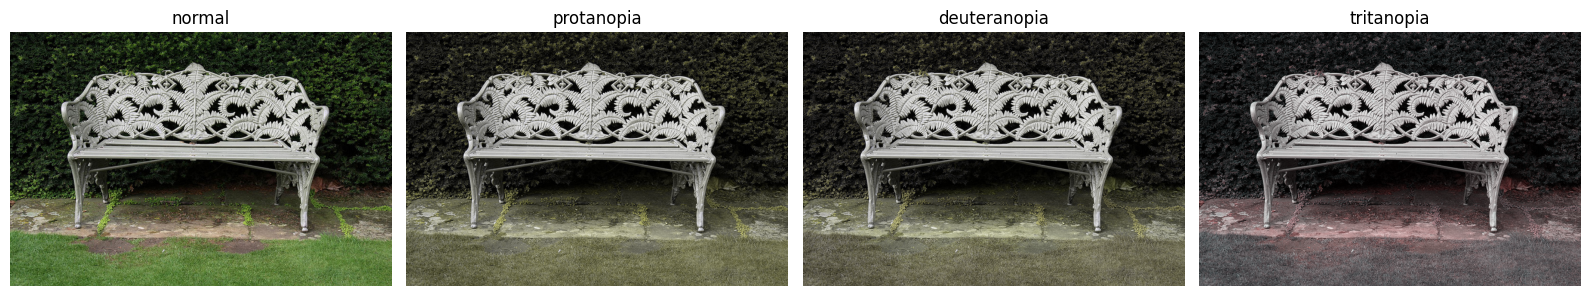

In [4]:
# Approximate color vision deficiency matrices (RGB -> RGB)
COLOR_MATRICES: Dict[str, np.ndarray] = {
    "protanopia": np.array([
        [0.56667, 0.43333, 0.00000],
        [0.55833, 0.44167, 0.00000],
        [0.00000, 0.24167, 0.75833],
    ], dtype=np.float32),
    "deuteranopia": np.array([
        [0.62500, 0.37500, 0.00000],
        [0.70000, 0.30000, 0.00000],
        [0.00000, 0.30000, 0.70000],
    ], dtype=np.float32),
    "tritanopia": np.array([
        [0.95000, 0.05000, 0.00000],
        [0.00000, 0.43333, 0.56667],
        [0.00000, 0.47500, 0.52500],
    ], dtype=np.float32),
}


def apply_color_matrix(arr: np.ndarray, mat: np.ndarray) -> np.ndarray:
    """Apply 3x3 color matrix to uint8 RGB image array."""
    h, w, _ = arr.shape
    flat = arr.reshape(-1, 3).astype(np.float32)
    out = flat @ mat.T
    out = np.clip(out, 0, 255).reshape(h, w, 3).astype(np.uint8)
    return out


def simulate_color_vision(image: Image.Image, mode: str) -> Image.Image:
    """Simulate color-vision condition: 'normal', 'protanopia', 'deuteranopia', 'tritanopia'."""
    if mode == "normal":
        return image
    if mode not in COLOR_MATRICES:
        raise ValueError(f"Unknown mode: {mode}")
    arr = np.array(image.convert("RGB"))
    mat = COLOR_MATRICES[mode]
    arr_cb = apply_color_matrix(arr, mat)
    return Image.fromarray(arr_cb)


# Quick sanity check on one random COCO image
sample_img = Image.open(random.choice(COCO_SAMPLES)["image_path"]).convert("RGB")
modes = ["normal", "protanopia", "deuteranopia", "tritanopia"]

plt.figure(figsize=(4 * len(modes), 4))
for i, m in enumerate(modes, 1):
    plt.subplot(1, len(modes), i)
    plt.imshow(simulate_color_vision(sample_img, m))
    plt.title(m)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
CATEGORIES: List[str] = COCO_CATEGORIES
PROMPTS: List[str] = [f"a photo of a {c}" for c in CATEGORIES]
LABEL_TO_IDX: Dict[str, int] = {c: i for i, c in enumerate(CATEGORIES)}


def predict_clip_for_image(
    img: Image.Image,
    model: CLIPModel,
    processor: CLIPProcessor,
    prompts: List[str],
    device: torch.device,
) -> Tuple[int, float, np.ndarray]:
    """Run CLIP and return (pred_idx, pred_prob, probs)."""
    inputs = processor(
        text=prompts,
        images=[img],
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image[0]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    pred_idx = int(probs.argmax())
    return pred_idx, float(probs[pred_idx]), probs


def evaluate_color_vision(
    samples: List[Dict[str, Any]],
    num_images: int = 200,
    modes: List[str] | None = None,
):
    if modes is None:
        modes = ["normal", "protanopia", "deuteranopia", "tritanopia"]

    results: Dict[str, Dict[str, int]] = {m: {"correct": 0, "total": 0} for m in modes}
    detailed: List[Dict[str, Any]] = []

    # num_images <= 0 means: use ALL available samples
    if num_images is None or num_images <= 0:
        subset = list(samples)
    else:
        if num_images > len(samples):
            num_images = len(samples)
        subset = random.sample(samples, num_images)

    for rec in tqdm(subset, desc="Evaluating"):
        img = Image.open(rec["image_path"]).convert("RGB")
        # Multi-label ground truth: all COCO categories present in this image
        gt_labels: List[str] = rec.get("category_names", [])
        gt_indices = {LABEL_TO_IDX[c] for c in gt_labels if c in LABEL_TO_IDX}
        if not gt_indices:
            continue

        row: Dict[str, Any] = {
            "image_path": rec["image_path"],
            "gt_labels": gt_labels,
            "per_mode": {},
        }

        for mode in modes:
            img_mod = simulate_color_vision(img, mode)
            pred_idx, pred_prob, probs = predict_clip_for_image(
                img_mod, clip_model, clip_processor, PROMPTS, device
            )
            pred_label = CATEGORIES[pred_idx]
            correct = int(pred_idx in gt_indices)

            results[mode]["correct"] += correct
            results[mode]["total"] += 1

            row["per_mode"][mode] = {
                "pred_label": pred_label,
                "pred_prob": pred_prob,
                "correct": bool(correct),
            }

        detailed.append(row)

    print("=== Accuracy by color-vision condition ===")
    for mode in modes:
        total = max(1, results[mode]["total"])
        acc = results[mode]["correct"] / total
        print(f"{mode:>10}: {acc:.3f}  ({results[mode]['correct']}/{results[mode]['total']})")

    return results, detailed


color_modes = ["normal", "protanopia", "deuteranopia", "tritanopia"]
# num_images <= 0 => use ALL COCO 2017 val samples
results_color, detailed_color = evaluate_color_vision(
    COCO_SAMPLES,
    num_images=0,
    modes=color_modes,
)


Evaluating:   1%|          | 35/4952 [00:02<06:17, 13.01it/s]


KeyboardInterrupt: 

In [ ]:
def show_example(row: Dict[str, Any], modes: List[str]) -> None:
    img = Image.open(row["image_path"]).convert("RGB")
    fig, axes = plt.subplots(1, len(modes), figsize=(4 * len(modes), 4))
    if len(modes) == 1:
        axes = [axes]

    gt_labels = row.get("gt_labels", [])
    gt_str = ", ".join(gt_labels) if gt_labels else "(none)"

    for ax, mode in zip(axes, modes):
        img_mod = simulate_color_vision(img, mode)
        info = row["per_mode"][mode]
        title = (
            f"{mode}\n"
            f"GT: {gt_str}\n"
            f"Pred: {info['pred_label']} ({'correct' if info['correct'] else 'wrong'})"
        )
        ax.imshow(img_mod)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Show a few random examples
num_examples = 3
for row in random.sample(detailed_color, min(num_examples, len(detailed_color))):
    show_example(row, modes=color_modes)


## 7. Color-Robustness Training Experiments (Optional)

Here we sketch four training variants on a **small COCO subset** to study which improves robustness to color-vision changes:

1. **baseline**: standard multi-label training.
2. **color_invariant**: strong color jitter + simulated CVD with a consistency loss.
3. **shape_biased**: grayscale / edge-like augmentations.
4. **adv_color**: adversarial-style color transform chosen from a small family.

Training is lightweight (few epochs on a subset) and intended for qualitative comparison, not full-scale CLIP retraining.

In [12]:
import math
from torch.utils.data import Dataset, DataLoader


class CocoColorDataset(Dataset):
    def __init__(self, samples: List[Dict[str, Any]], max_images: int | None = 5000):
        if max_images is not None and max_images > 0:
            self.samples = random.sample(samples, min(max_images, len(samples)))
        else:
            self.samples = list(samples)

    def __len__(self) -> int:  # type: ignore[override]
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, Any]:  # type: ignore[override]
        rec = self.samples[idx]
        img = Image.open(rec["image_path"]).convert("RGB")
        gt_labels = rec.get("category_names", [])
        gt_indices = [LABEL_TO_IDX[c] for c in gt_labels if c in LABEL_TO_IDX]
        target = np.zeros(len(CATEGORIES), dtype=np.float32)
        for j in gt_indices:
            target[j] = 1.0
        return {"image": img, "target": torch.from_numpy(target)}


def coco_collate_fn(batch: list[Dict[str, Any]]) -> Dict[str, Any]:
    images = [b["image"] for b in batch]
    targets = torch.stack([b["target"] for b in batch])
    return {"image": images, "target": targets}


def make_dataloader(split_ratio: float = 0.8, batch_size: int = 32, max_images: int | None = 5000):
    dataset = CocoColorDataset(COCO_SAMPLES, max_images=max_images)
    n = len(dataset)
    n_train = int(split_ratio * n)
    indices = list(range(n))
    random.shuffle(indices)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:]

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)

    # On Windows notebooks, use num_workers=0 and custom collate to avoid hanging
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=coco_collate_fn,
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=coco_collate_fn,
    )
    return train_loader, val_loader


In [13]:
def color_jitter_pil(img: Image.Image) -> Image.Image:
    # Simple handmade jitter to avoid extra deps
    arr = np.array(img).astype(np.float32)
    # Brightness and contrast
    b = 0.6 + 0.8 * np.random.rand()  # [0.6, 1.4]
    c = 0.6 + 0.8 * np.random.rand()
    mean = arr.mean(axis=(0, 1), keepdims=True)
    arr = (arr - mean) * c + mean
    arr *= b
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def to_grayscale_pil(img: Image.Image) -> Image.Image:
    return img.convert("L").convert("RGB")


def edge_like_pil(img: Image.Image) -> Image.Image:
    # crude edge-like representation via Sobel on grayscale
    import cv2

    gray = np.array(img.convert("L"))
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    mag = mag / (mag.max() + 1e-6) * 255.0
    mag = mag.astype(np.uint8)
    return Image.fromarray(mag).convert("RGB")


def sample_cvd_mode() -> str:
    return random.choice(["protanopia", "deuteranopia", "tritanopia"])

In [14]:
def bce_multi_label_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    # logits: (B, C), targets: (B, C) with 0/1
    return torch.nn.functional.binary_cross_entropy_with_logits(logits, targets)


def forward_clip_multi(
    images: List[Image.Image],
    prompts: List[str],
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
) -> torch.Tensor:
    inputs = processor(
        text=prompts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)
    with torch.no_grad():
        # we treat logits_per_image as fixed and only train a small head
        out = model(**inputs)
        logits = out.logits_per_image  # (B, num_prompts)
    return logits


In [17]:
def train_color_robust_variant(
    variant: str,
    epochs: int = 1,
    max_images: int | None = 2000,
    batch_size: int = 32,
    lambda_consistency: float = 1.0,
) -> Tuple[torch.nn.Module, Dict[str, float]]:
    """Train lightweight variants; returns (trained head, metrics dict).

    Variants:
    - "baseline"
    - "color_invariant"
    - "shape_biased"
    - "adv_color"
    """
    train_loader, val_loader = make_dataloader(batch_size=batch_size, max_images=max_images)

    # Small trainable linear head on top of frozen CLIP logits
    head = torch.nn.Linear(len(CATEGORIES), len(CATEGORIES), bias=True).to(device)
    optim = torch.optim.Adam(head.parameters(), lr=1e-3)

    def make_aug(img: Image.Image, mode: str) -> Image.Image:
        if mode == "baseline":
            return img
        if mode == "color_invariant":
            img2 = color_jitter_pil(img)
            if np.random.rand() < 0.5:
                img2 = simulate_color_vision(img2, sample_cvd_mode())
            return img2
        if mode == "shape_biased":
            if np.random.rand() < 0.5:
                return to_grayscale_pil(img)
            return edge_like_pil(img)
        if mode == "adv_color":
            # candidate color transforms
            candidates = [
                lambda x: color_jitter_pil(x),
                lambda x: to_grayscale_pil(x),
                lambda x: simulate_color_vision(x, "protanopia"),
                lambda x: simulate_color_vision(x, "deuteranopia"),
                lambda x: simulate_color_vision(x, "tritanopia"),
            ]
            # pick one at random; for full adversarial search we would score each
            fn = random.choice(candidates)
            return fn(img)
        raise ValueError(f"Unknown variant: {mode}")

    def run_epoch(loader, train: bool) -> float:
        if train:
            head.train()
            desc = f"{variant} train"
        else:
            head.eval()
            desc = f"{variant} val"
        total_loss = 0.0
        n_batches = 0
        for batch in tqdm(loader, desc=desc, leave=False):
            imgs: List[Image.Image] = list(batch["image"])
            targets: torch.Tensor = batch["target"].to(device)

            imgs_aug = [make_aug(img, variant) for img in imgs]

            with torch.no_grad():
                logits_orig = forward_clip_multi(imgs, PROMPTS, clip_model, clip_processor, device)
                logits_aug = forward_clip_multi(imgs_aug, PROMPTS, clip_model, clip_processor, device)

            logits_head_orig = head(logits_orig)
            loss_cls = bce_multi_label_loss(logits_head_orig, targets)

            loss = loss_cls
            if variant in {"color_invariant", "shape_biased", "adv_color"}:
                logits_head_aug = head(logits_aug)
                # encourage invariance: MSE between logits
                loss_cons = torch.mean((logits_head_orig - logits_head_aug) ** 2)
                loss = loss_cls + lambda_consistency * loss_cons

            if train:
                optim.zero_grad()
                loss.backward()
                optim.step()

            total_loss += float(loss.detach().cpu().item())
            n_batches += 1

        return total_loss / max(1, n_batches)

    metrics: Dict[str, float] = {}
    for ep in range(epochs):
        train_loss = run_epoch(train_loader, train=True)
        val_loss = run_epoch(val_loader, train=False)
        print(f"[{variant}] Epoch {ep+1}/{epochs} - train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        metrics[f"train_loss_ep{ep+1}"] = train_loss
        metrics[f"val_loss_ep{ep+1}"] = val_loss

    return head, metrics


In [18]:
# Run all four variants once (small subset, 1 epoch each).
# You can increase epochs or max_images for more serious training.
variants = ["baseline", "color_invariant", "shape_biased", "adv_color"]
all_metrics: Dict[str, Dict[str, float]] = {}
for v in variants:
    print(f"\n=== Training variant: {v} ===")
    all_metrics[v] = train_color_robust_variant(
        variant=v,
        epochs=1,
        max_images=2000,
        batch_size=64,
        lambda_consistency=1.0,
    )

all_metrics



=== Training variant: baseline ===


[baseline] Epoch 1/1 - train_loss=1.2937, val_loss=0.2337

=== Training variant: color_invariant ===


[color_invariant] Epoch 1/1 - train_loss=1.2898, val_loss=0.5139

=== Training variant: shape_biased ===


[shape_biased] Epoch 1/1 - train_loss=1.9718, val_loss=0.9845

=== Training variant: adv_color ===


[adv_color] Epoch 1/1 - train_loss=1.5050, val_loss=0.5635


{'baseline': (Linear(in_features=80, out_features=80, bias=True),
  {'train_loss_ep1': 1.2936990785598754, 'val_loss_ep1': 0.23374920657702855}),
 'color_invariant': (Linear(in_features=80, out_features=80, bias=True),
  {'train_loss_ep1': 1.2898415899276734, 'val_loss_ep1': 0.5139258546488625}),
 'shape_biased': (Linear(in_features=80, out_features=80, bias=True),
  {'train_loss_ep1': 1.9718448543548583, 'val_loss_ep1': 0.9845386062349591}),
 'adv_color': (Linear(in_features=80, out_features=80, bias=True),
  {'train_loss_ep1': 1.5050068426132202, 'val_loss_ep1': 0.5634691076619285})}

In [19]:
from tqdm import tqdm

def evaluate_color_vision_with_head(
    samples: List[Dict[str, Any]],
    head: torch.nn.Module,
    num_images: int = 500,
    modes: List[str] | None = None,
):
    """
    Same setup as evaluate_color_vision, but passes CLIP logits through a trained head.
    """
    if modes is None:
        modes = ["normal", "protanopia", "deuteranopia", "tritanopia"]

    head = head.to(device).eval()
    results: Dict[str, Dict[str, int]] = {m: {"correct": 0, "total": 0} for m in modes}

    if num_images is None or num_images <= 0:
        subset = list(samples)
    else:
        num_images = min(num_images, len(samples))
        subset = random.sample(samples, num_images)

    for rec in tqdm(subset, desc="Evaluating (head)", leave=False):
        img = Image.open(rec["image_path"]).convert("RGB")
        gt_labels: List[str] = rec.get("category_names", [])
        gt_indices = {LABEL_TO_IDX[c] for c in gt_labels if c in LABEL_TO_IDX}
        if not gt_indices:
            continue

        for mode in modes:
            img_mod = simulate_color_vision(img, mode)
            inputs = clip_processor(
                text=PROMPTS,
                images=[img_mod],
                return_tensors="pt",
                padding=True,
                truncation=True,
            ).to(device)

            with torch.no_grad():
                out = clip_model(**inputs)
                logits_clip = out.logits_per_image  # (1, num_classes)
                logits_head = head(logits_clip)[0]
                probs_head = torch.softmax(logits_head, dim=-1).cpu().numpy()

            pred_idx = int(probs_head.argmax())
            correct = int(pred_idx in gt_indices)
            results[mode]["correct"] += correct
            results[mode]["total"] += 1

    print("=== Accuracy by color-vision condition (with head) ===")
    for mode in modes:
        total = max(1, results[mode]["total"])
        acc = results[mode]["correct"] / total
        print(f"{mode:>10}: {acc:.3f}  ({results[mode]['correct']}/{results[mode]['total']})")

    return results


# ---- Run inference for original CLIP vs all variants ----

color_modes = ["normal", "protanopia", "deuteranopia", "tritanopia"]
num_eval_images = 500  # keep moderate for speed

print("Original CLIP (no head):")
_ = evaluate_color_vision(
    COCO_SAMPLES,
    num_images=num_eval_images,
    modes=color_modes,
)

# all_metrics was built in the training cell as:
# {'baseline': (head, metrics), 'color_invariant': (head, metrics), ...}
print("\nCLIP + trained heads:")
for name, (head, metrics) in all_metrics.items():
    print(f"\nVariant: {name}")
    _ = evaluate_color_vision_with_head(
        COCO_SAMPLES,
        head=head,
        num_images=num_eval_images,
        modes=color_modes,
    )

Original CLIP (no head):


Evaluating: 100%|██████████| 500/500 [00:33<00:00, 14.94it/s]


=== Accuracy by color-vision condition ===
    normal: 0.832  (416/500)
protanopia: 0.802  (401/500)
deuteranopia: 0.796  (398/500)
tritanopia: 0.800  (400/500)

CLIP + trained heads:


NameError: name 'all_results' is not defined